In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

# Load dataset
data = pd.read_csv("calories.csv")

# Encode Gender (text → number)
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

# Features & Target
X = data.drop("Calories", axis=1)
y = data["Calories"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluate
print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.9975570213704356
MAE: 1.8828799999999999


In [3]:
def classify_fitness(cal):
    if cal < 100:
        return 0   # Unfit
    elif cal < 300:
        return 1   # Moderate
    else:
        return 2   # Fit

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create fitness category
data['Fitness_Level'] = data['Calories'].apply(classify_fitness)

# Features & target
X = data.drop(['Calories', 'Fitness_Level'], axis=1)
y = data['Fitness_Level']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Accuracy
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

Classification Accuracy: 0.9826666666666667


In [5]:
nutrition = pd.read_csv("./health_fitness_dataset.csv")
print(nutrition.head())

   participant_id      date  age gender  height_cm  weight_kg    bmi  \
0               1  2024/1/1   56      F      165.3      50.55  18.50   
1               1  2024/1/4   56      F      165.3      55.38  20.27   
2               1  2024/1/5   56      F      165.3      56.49  20.68   
3               1  2024/1/7   56      F      165.3      52.23  19.12   
4               1  2024/1/9   56      F      165.3      53.96  19.75   

     activity_type  duration_minutes intensity  ...  resting_heart_rate  \
0          Dancing              42.1       Low  ...                69.5   
1         Swimming              66.9       Low  ...                69.5   
2         Swimming              20.0    Medium  ...                69.5   
3  Weight Training              23.5    Medium  ...                69.5   
4         Swimming              75.0    Medium  ...                69.5   

   blood_pressure_systolic  blood_pressure_diastolic  endurance_level  \
0                    110.7                 

In [6]:
fitness = pd.read_csv("./health_fitness_dataset.csv")

# Remove missing values
fitness = fitness.dropna()

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

fitness['gender'] = le.fit_transform(fitness['gender'])
fitness['activity_type'] = le.fit_transform(fitness['activity_type'])
fitness['intensity'] = le.fit_transform(fitness['intensity'])
fitness['smoking_status'] = le.fit_transform(fitness['smoking_status'])

In [8]:
X = fitness.drop(['activity_type', 'date', 'participant_id'], axis=1)
y = fitness['activity_type']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

workout_model = RandomForestClassifier()
workout_model.fit(X_train, y_train)

pred = workout_model.predict(X_test)

print("Workout Model Accuracy:", accuracy_score(y_test, pred))

ValueError: could not convert string to float: 'Hypertension'

In [10]:
fitness = fitness.drop(['date', 'participant_id'], axis=1)

In [11]:
print(fitness.dtypes)

age                           int64
gender                        int64
height_cm                   float64
weight_kg                   float64
bmi                         float64
activity_type                 int64
duration_minutes            float64
intensity                     int64
calories_burned             float64
daily_steps                   int64
avg_heart_rate                int64
resting_heart_rate          float64
blood_pressure_systolic     float64
blood_pressure_diastolic    float64
endurance_level             float64
sleep_hours                 float64
stress_level                  int64
hydration_level             float64
smoking_status                int64
health_condition             object
fitness_level               float64
dtype: object


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in fitness.columns:
    if fitness[col].dtype == 'object':
        fitness[col] = le.fit_transform(fitness[col])

In [13]:
X = fitness.drop('activity_type', axis=1)
y = fitness['activity_type']

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.40621992604973917


In [16]:
X = fitness.drop(['activity_type'], axis=1)

# Drop noisy columns if present
X = X.drop(['participant_id'], axis=1, errors='ignore')

In [17]:
X = fitness[['age', 'bmi', 'duration_minutes', 'intensity',
             'resting_heart_rate', 'sleep_hours', 'stress_level']]

In [18]:
y = fitness['activity_type']

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, pred))

Improved Accuracy: 0.14354454743453376


In [22]:
y = fitness['intensity']

In [23]:
X = fitness.drop(['intensity'], axis=1)

In [24]:
X = fitness.drop(['intensity'], axis=1)

In [26]:
X = X.drop(['participant_id', 'date'], axis=1, errors='ignore')

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, pred))

New Accuracy: 0.842627766803424


In [42]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 0.24760674669503116
R2 Score: 0.3068418794979161


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [ ]:
model = RandomForestRegressor(n_estimators=200, max_depth=10)

<Axes: >

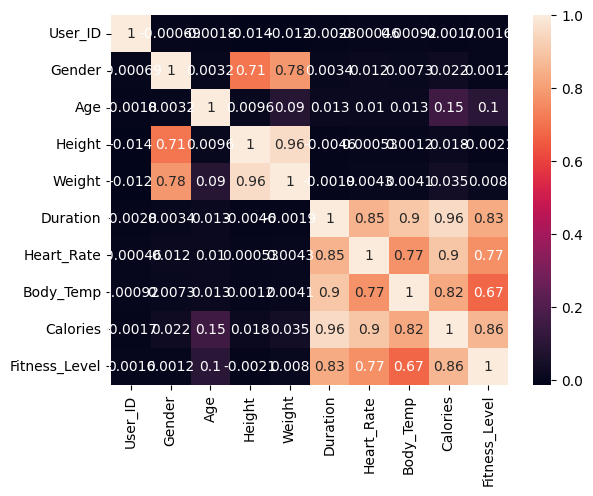

In [ ]:
import seaborn as sns
sns.heatmap(data.corr(), annot=True)

In [45]:
def fitness_level(row):
    if row['Calories'] < 100:
        return 0   # Unfit
    elif row['Calories'] < 200:
        return 1   # Moderate
    else:
        return 2   # Fit

data['Fitness_Level'] = data.apply(fitness_level, axis=1)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.838449070556653
              precision    recall  f1-score   support

           0       0.84      0.67      0.75      7815
           1       0.87      0.90      0.88     11878
           2       0.82      0.87      0.84     19793

    accuracy                           0.84     39486
   macro avg       0.84      0.81      0.82     39486
weighted avg       0.84      0.84      0.84     39486



In [48]:
model = RandomForestClassifier(class_weight='balanced')

In [49]:
q1 = data['Calories'].quantile(0.33)
q2 = data['Calories'].quantile(0.66)

def fitness_level(x):
    if x < q1:
        return 0
    elif x < q2:
        return 1
    else:
        return 2

In [50]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [51]:
import pandas as pd

food = pd.read_excel("./nutrition.xlsx")
print(food.head())

   Unnamed: 0             name serving_size  calories total_fat saturated_fat  \
0           0       Cornstarch        100 g       381      0.1g           NaN   
1           1     Nuts, pecans        100 g       691       72g          6.2g   
2           2    Eggplant, raw        100 g        25      0.2g           NaN   
3           3   Teff, uncooked        100 g       367      2.4g          0.4g   
4           4  Sherbet, orange        100 g       144        2g          1.2g   

  cholesterol    sodium  choline     folate  ...      fat  \
0           0   9.00 mg   0.4 mg   0.00 mcg  ...   0.05 g   
1           0   0.00 mg  40.5 mg  22.00 mcg  ...  71.97 g   
2           0   2.00 mg   6.9 mg  22.00 mcg  ...   0.18 g   
3           0  12.00 mg  13.1 mg          0  ...   2.38 g   
4         1mg  46.00 mg   7.7 mg   4.00 mcg  ...   2.00 g   

  saturated_fatty_acids monounsaturated_fatty_acids  \
0               0.009 g                     0.016 g   
1               6.180 g             

In [52]:
food = food.drop(columns=['Unnamed: 0'])

In [53]:
food = food[['name', 'calories', 'protein', 'carbohydrate', 'fat']]

In [54]:
print(food.columns)

Index(['name', 'calories', 'protein', 'carbohydrate', 'fat'], dtype='object')


In [55]:
def clean_column(col):
    return col.astype(str).str.replace('g', '').str.replace('mg', '').str.replace('mcg', '').astype(float)

food['fat'] = clean_column(food['fat'])
food['protein'] = clean_column(food['protein'])
food['carbohydrate'] = clean_column(food['carbohydrate'])

In [56]:
food = food.dropna()

In [57]:
food.rename(columns={
    'name': 'Food',
    'calories': 'Calories',
    'protein': 'Protein',
    'carbohydrate': 'Carbs',
    'fat': 'Fat'
}, inplace=True)

In [58]:
def diet_plan(goal):
    if goal == "weight_loss":
        return food[food['Calories'] < 200].sort_values(by='Calories').head(5)
    
    elif goal == "muscle_gain":
        return food[food['Protein'] > 10].sort_values(by='Protein', ascending=False).head(5)
    
    else:
        return food.head(5)

print(diet_plan("muscle_gain"))

                                                   Food  Calories  Protein  \
1378                Soy protein isolate, potassium type       321    88.32   
213                                 Soy protein isolate       335    88.32   
1618                  Gelatins, unsweetened, dry powder       335    85.60   
3893     Egg, glucose reduced, stabilized, dried, white       357    84.08   
4401  Seal, dried (Alaska Native), meat, bearded (Oo...       351    82.60   

      Carbs   Fat  
1378   2.59  0.53  
213    0.00  3.39  
1618   0.00  0.10  
3893   4.51  0.32  
4401   0.00  2.30  


In [59]:
def balanced_diet():
    return food.sort_values(by=['Protein', 'Calories'], ascending=[False, True]).head(5)

In [60]:
def full_system(age, weight, height, duration, heart_rate, goal):

    # Prepare input
    input_data = [[age, weight, height, duration, heart_rate]]

    # 1. Calories Prediction
    calories = model.predict(input_data)[0]

    # 2. Fitness Level
    fitness = model_clf.predict(input_data)[0]

    # Convert fitness label
    if fitness == 0:
        fitness_label = "Unfit"
    elif fitness == 1:
        fitness_label = "Moderate"
    else:
        fitness_label = "Fit"

    # 3. Diet Recommendation
    diet = diet_plan(goal)

    return {
        "Calories Burned": calories,
        "Fitness Level": fitness_label,
        "Recommended Diet": diet[['Food', 'Calories', 'Protein']]
    }

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Gender'] = le.fit_transform(data['Gender'])

In [63]:
print(data.dtypes)

User_ID            int64
Gender             int64
Age                int64
Height           float64
Weight           float64
Duration         float64
Heart_Rate       float64
Body_Temp        float64
Calories         float64
Fitness_Level      int64
dtype: object


In [70]:
print(data.columns)

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories', 'Fitness_Level'],
      dtype='object')


In [71]:
data = data.drop('User_ID', axis=1)

In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

In [73]:
X = data[['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']]
y = data['Calories']

In [74]:
X_clf = data[['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']]
y_clf = data['Fitness_Level']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

# Models
model = RandomForestRegressor()
model_clf = RandomForestClassifier()

# Calories Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Calories Model:")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))


# Fitness Model
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
model_clf.fit(X_train_c, y_train_c)

pred_c = model_clf.predict(X_test_c)

print("\nFitness Model:")
print("Accuracy:", accuracy_score(y_test_c, pred_c))

In [77]:
input_data = pd.DataFrame([[1, 25, 170, 70, 30, 120, 36.5]],
columns=['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp'])

print(model.predict(input_data))
print(model_clf.predict(input_data))

[227.8]
[1]


In [78]:
calories = model.predict(input_data)[0]
fitness = model_clf.predict(input_data)[0]

print("Calories Burned:", calories)

if fitness == 0:
    print("Fitness Level: Unfit")
elif fitness == 1:
    print("Fitness Level: Moderate")
else:
    print("Fitness Level: Fit")

Calories Burned: 227.8
Fitness Level: Moderate


In [79]:
import joblib

joblib.dump(model, "calorie_model.pkl")
joblib.dump(model_clf, "fitness_model.pkl")

['fitness_model.pkl']

In [80]:
print(data['Calories'].describe())

count    15000.000000
mean        89.539533
std         62.456978
min          1.000000
25%         35.000000
50%         79.000000
75%        138.000000
max        314.000000
Name: Calories, dtype: float64


In [82]:
scaler.fit_transform(X)

array([[ 1.00709181,  1.48472604,  1.08958204, ...,  1.61912727,
         0.98940395,  0.99402302],
       [-0.99295813, -1.34217934, -0.59372619, ..., -0.1839901 ,
        -0.15846102,  0.3523425 ],
       [ 1.00709181,  1.5436199 ,  0.31806577, ..., -1.26586052,
        -0.78456918, -1.70103518],
       ...,
       [-0.99295813,  0.01237949, -1.08469109, ...,  0.05642555,
        -0.57586646,  0.09567029],
       [ 1.00709181,  2.07366466,  1.29999557, ..., -1.62648399,
        -1.20197462, -2.21437961],
       [ 1.00709181,  1.19025673, -0.10276129, ...,  0.2968412 ,
        -0.36716374,  0.60901471]], shape=(15000, 7))

In [81]:
from sklearn.preprocessing import StandardScaler

In [83]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [84]:
scaler = joblib.load("scaler.pkl")

In [85]:
input_data = scaler.transform(input_data)

In [86]:
print(X.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='object')


In [87]:
test = X.iloc[0:1]
print(test)
print(model.predict(test))

   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0       1   68   190.0    94.0      29.0       105.0       40.8
[229.82]


In [88]:
def diet_plan(goal):
    if goal == "weight_loss":
        return food[food['Calories'] < 200].head(5)

In [89]:
def diet_plan(calories, goal):
    
    if goal == "weight_loss":
        return food[food['Calories'] <= calories * 0.5].sort_values(by='Calories').head(5)
    
    elif goal == "muscle_gain":
        return food[(food['Protein'] > 10) & (food['Calories'] <= calories)].sort_values(by='Protein', ascending=False).head(5)
    
    else:
        return food.head(5)

In [91]:
food = pd.read_excel("./nutrition.xlsx")

# Clean columns
food.columns = food.columns.str.strip()

# Select important columns
food = food[['name', 'calories', 'protein', 'carbohydrate', 'fat']]

# Rename
food.rename(columns={
    'name': 'Food',
    'calories': 'Calories',
    'protein': 'Protein',
    'carbohydrate': 'Carbs',
    'fat': 'Fat'
}, inplace=True)

# Clean units
def clean_column(col):
    return col.astype(str).str.replace('g', '').str.replace('mg', '').str.replace('mcg', '').astype(float)

food['Protein'] = clean_column(food['Protein'])
food['Carbs'] = clean_column(food['Carbs'])
food['Fat'] = clean_column(food['Fat'])

food = food.dropna()

In [92]:
def diet_plan(calories, goal):

    if goal == "weight_loss":
        return food[food['Calories'] <= calories * 0.5].sort_values(by='Calories').head(5)

    elif goal == "muscle_gain":
        return food[(food['Protein'] > 10) & (food['Calories'] <= calories)].sort_values(by='Protein', ascending=False).head(5)

    else:
        return food.head(5)

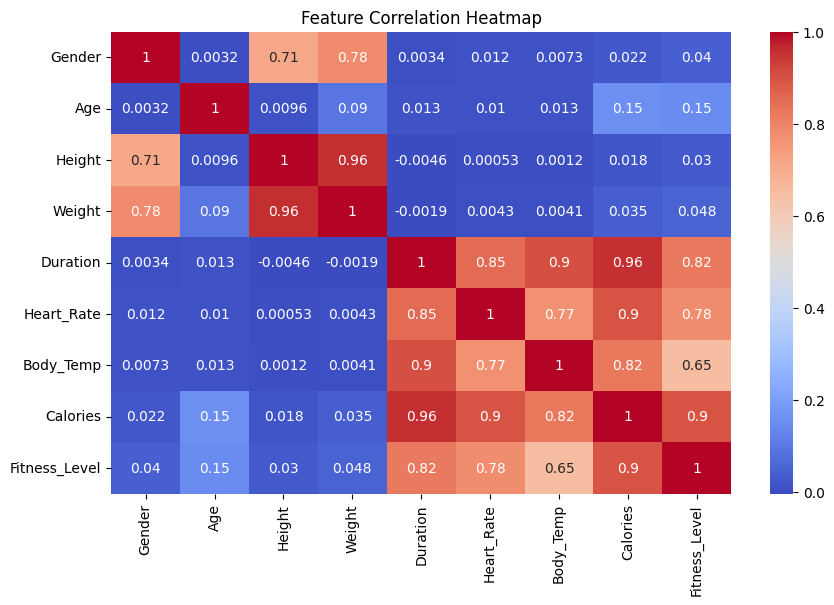

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

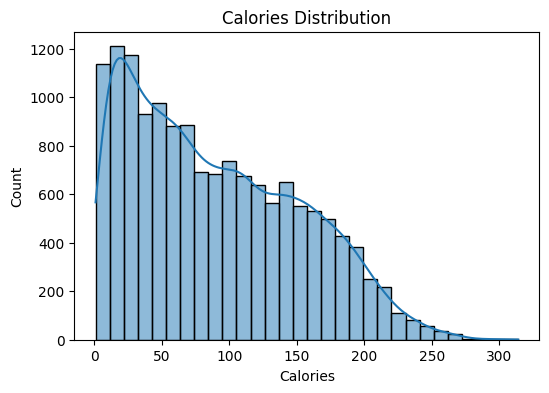

In [95]:
plt.figure(figsize=(6,4))
sns.histplot(data['Calories'], bins=30, kde=True)
plt.title("Calories Distribution")
plt.show()

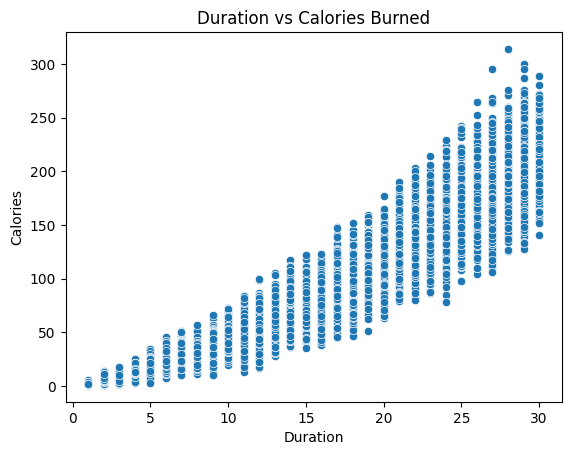

In [96]:
sns.scatterplot(x=data['Duration'], y=data['Calories'])
plt.title("Duration vs Calories Burned")
plt.show()

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = r2_score(y_test, pred)

print(results)

{'Linear Regression': 0.9672937151257295, 'Random Forest': 0.9982540085450625, 'XGBoost': 0.9988678909361673}


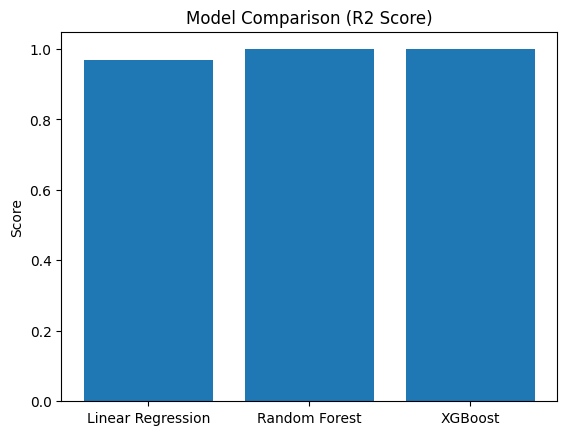

In [98]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (R2 Score)")
plt.ylabel("Score")
plt.show()

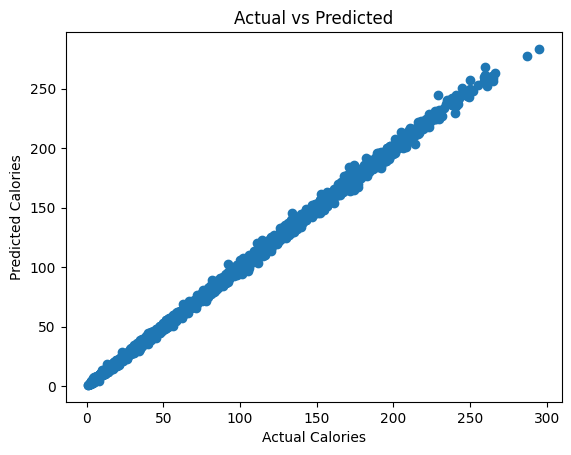

In [99]:
pred = model.predict(X_test)

plt.scatter(y_test, pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")
plt.show()

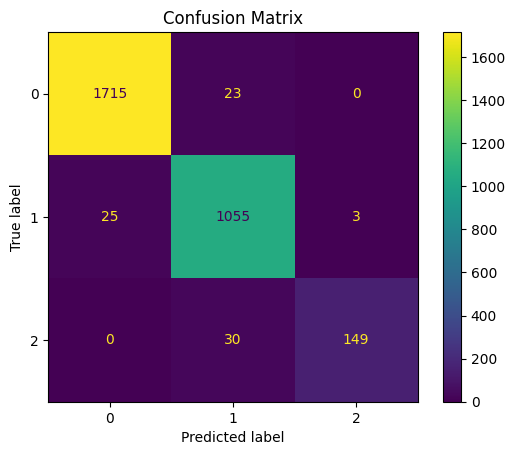

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_c, pred_c)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

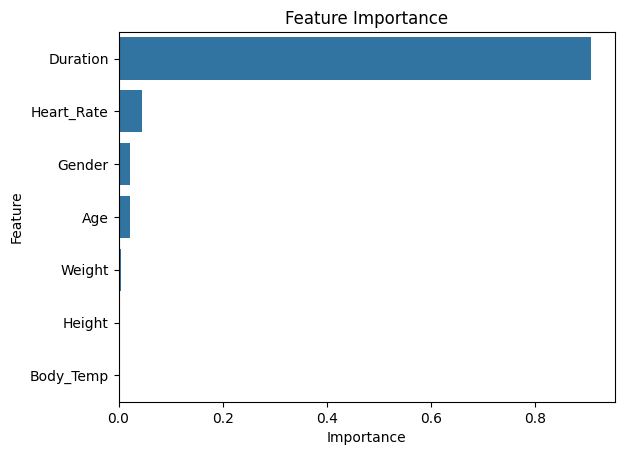

In [101]:
import pandas as pd

importance = model.feature_importances_

feature_names = X.columns

df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

df = df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=df)
plt.title("Feature Importance")
plt.show()